In [7]:
import json
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Callable, Dict, Union
import sys

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

import arviz as az

# src directory
parent_dir = Path.cwd().parent.parent 
sys.path.append(str(parent_dir))

print(parent_dir)
from tools.myutils import plot_act_density, plot_location

/home/pim/pg-rad-analysis/src


In [12]:
SIM_NAME = ''
SIM_NAME = 'fwhm_2_'

## Loading scenario, original parameters and posterior data

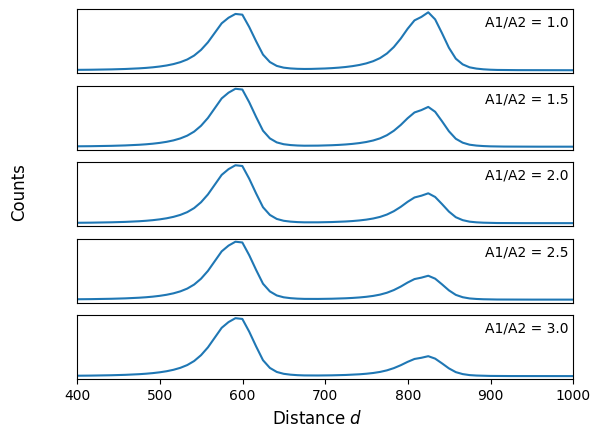

In [14]:
SIM_ID = [1., 1.5, 2., 2.5, 3.]
result_dict = {}

SIM_PER_D = 10

fig, axs = plt.subplots(len(SIM_ID))
fig.supxlabel('Distance $d$')
fig.supylabel('Counts')

for i, sim in enumerate(SIM_ID):
    traces = []
    for j in range(SIM_PER_D):
        traces.append(az.from_netcdf(f"trace_output/{sim}_{SIM_NAME}trace_{j}"))
        df_i = pd.read_pickle(f"trace_output/{sim}_pkl_{j}")
        with open(f"trace_output/{sim}_real_params_{j}", 'r') as file:
            real_params = json.load(file)
        real_params_i = {int(k):v for k,v in real_params.items()}

    axs[i].plot(df_i["Dist"], df_i["ROI_P"])
    axs[i].text(0.99, 0.91, "A1/A2 = "+str(sim), transform=axs[i].transAxes, ha='right', va='top')
    axs[i].set_yticks([])
    axs[i].set_xlim((400, 1000))
    
    if i <= (len(SIM_ID) - 2):
        axs[i].set_xticks([])

    result_dict[sim] = {'traces': traces, 'df': df_i, 'real_params': real_params_i}

plt.savefig('source-diff-bayesian-test.png')

## Posterior analysis

In [16]:
ard_list = []
rpd_list = []

real_acts_list = []

for sim in SIM_ID:
    rp = result_dict[sim]['real_params']
    
    real_acts = np.array([rp[1]['act'], rp[2]['act']]).T
    real_x, real_y = np.array([rp[1]['x'], rp[2]['x']]).T, np.array([rp[1]['y'], rp[2]['y']]).T

    ard_ls = []
    rpd_ls = []
    
    for j in range(SIM_PER_D):
        trace = result_dict[sim]['traces'][j]
        posterior = trace.posterior
        x_samples = posterior.x_src.stack(sample=("chain","draw")).transpose("sources","sample").values
        y_samples = posterior.y_src.stack(sample=("chain","draw")).transpose("sources","sample").values
        a_samples = posterior.act_src.stack(sample=("chain","draw")).transpose("sources","sample").values
    
        x_mean = x_samples.mean(axis=1)
        y_mean = y_samples.mean(axis=1)
    
        r_real = np.sqrt(real_x**2 + real_y**2)
        r_est = np.sqrt(x_mean**2 + y_mean**2)
    
        act_mean = a_samples.mean(axis=1)
    
        ARD = np.abs(act_mean - real_acts) / real_acts * 100
        RPD = np.abs(r_est - r_real) / r_real * 100
    
        ard_ls.append(ARD)
        rpd_ls.append(RPD)

    ard_list.append(ard_ls)
    rpd_list.append(rpd_ls)
    real_acts_list.append(real_acts)

ard_arr = np.array(ard_list)
rpd_arr = np.array(rpd_list)

print('ARD shape', ard_arr.shape)
print('RPD shape', rpd_arr.shape)

ARD shape (5, 10, 2)
RPD shape (5, 10, 2)


Along axis 2, we have ARD/RPD of the 2 sources in a single scenario.

With 10 simulations, this means 20 values of ARD/RPD per scenario.

The LP is then defined as the number of ARD/RPD that are below 30%, divided by 20 (2x10).

Thus, to determine the ARD/RPD, we first make a boolean array across the scenarios.

In [17]:
is_located = (ard_arr < 30) & (rpd_arr < 30)

Then, we sum across the 2 sources and 10 scenarios (2x10) and multiply by 5 (100/20) to get the localization probability in percent.

In [18]:
LP = is_located.sum(axis=(1, 2)) * 5

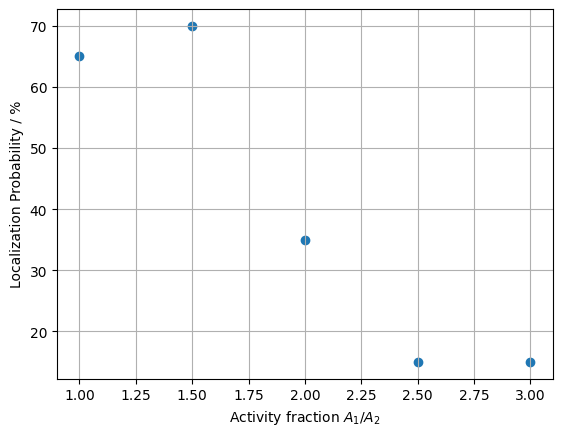

In [19]:
plt.scatter(SIM_ID, LP)
plt.xlabel('Activity fraction $A_1/A_2$')
plt.ylabel('Localization Probability / %')
plt.grid()
plt.savefig(f'2_src_dist_LP_{SIM_NAME}.png')

## Manual posterior analysis

Here one can view the posterior draws for position and activity for individual runs. For each configuration, the `j`-th simulation's posteriors are shown.

In [18]:
j = 1

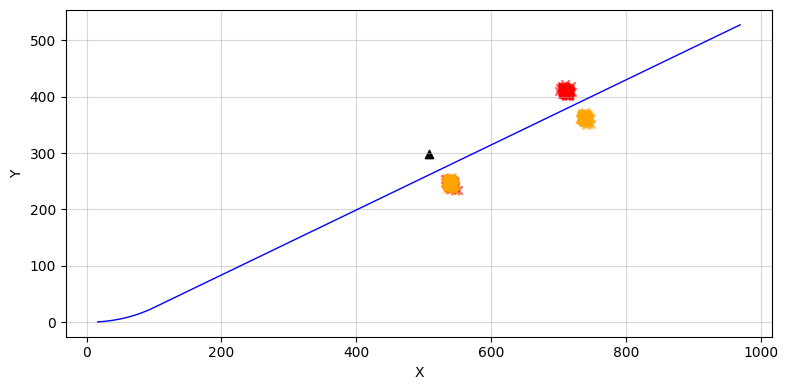

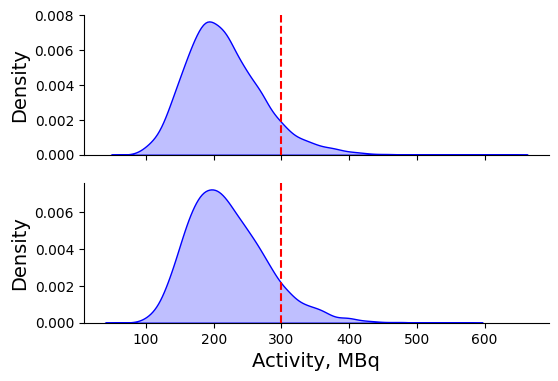

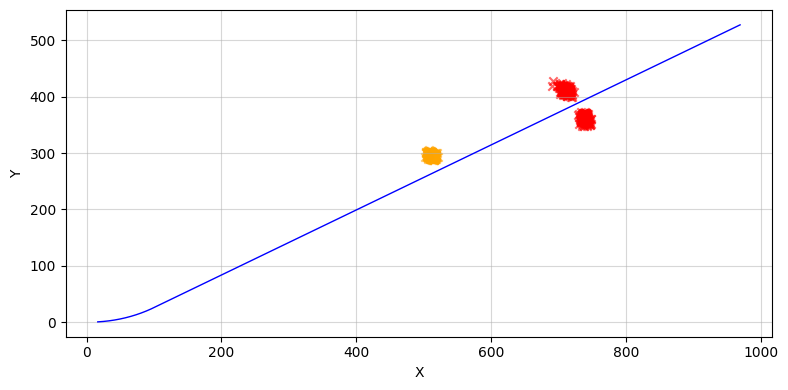

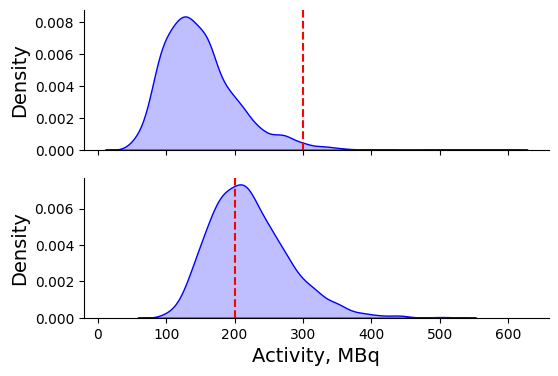

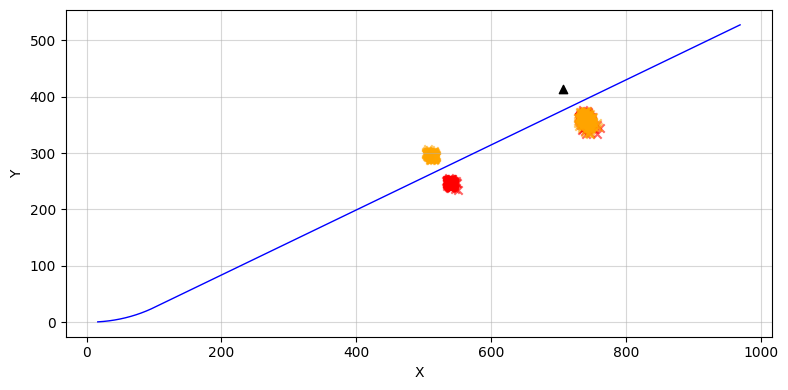

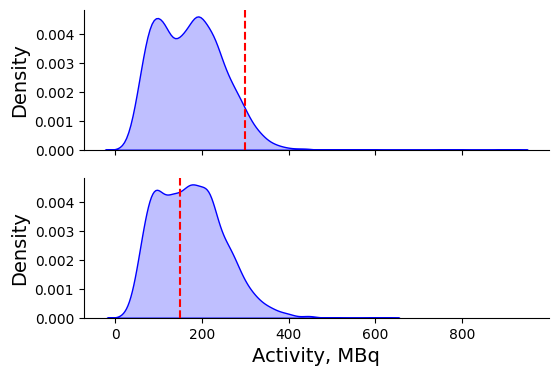

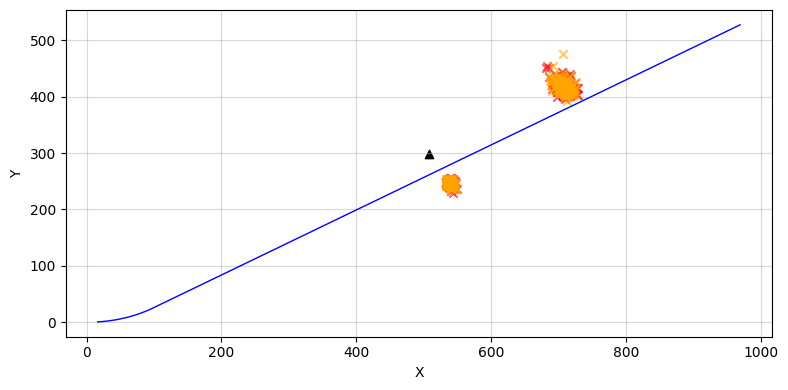

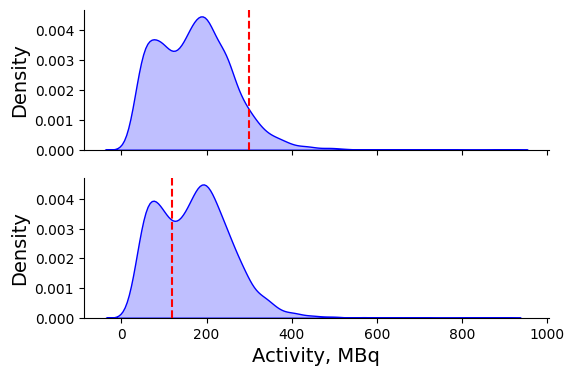

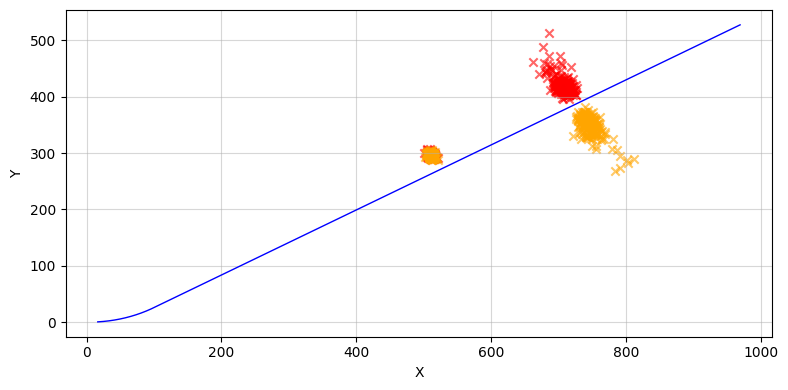

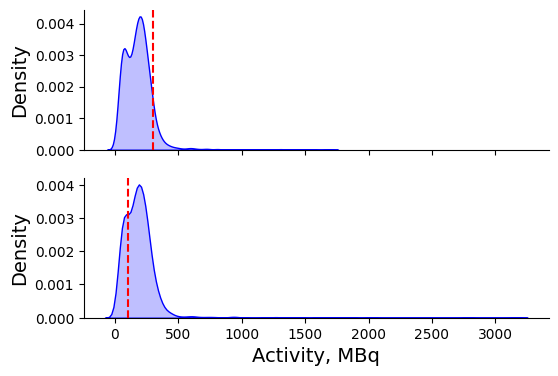

In [19]:
for i, (k, v) in enumerate(result_dict.items()):

    posterior = v['traces'][j].posterior
    n_sources = posterior.sizes["sources"]
    act_samples = {}
    
    for n in range(n_sources):
        act_samples[n+1] = (
            posterior["act_src"]
            .sel(sources=n)
            .values
            .reshape(-1)
        )
    
    x_samples = posterior.x_src.stack(sample=("chain","draw")).transpose("sources","sample").values
    y_samples = posterior.y_src.stack(sample=("chain","draw")).transpose("sources","sample").values

    ref_coords_x = [v['real_params'][j+1].get("x") for j in range(len(v['real_params']))]
    ref_coords_y = [v['real_params'][j+1].get("y") for j in range(len(v['real_params']))]

    plot_location(
        v['df'],
        ref_coords_x,
        ref_coords_y,
        x_samples,
        y_samples
    )

    plot_act_density(act_samples, true_act=real_acts_list[i])